              precision    recall  f1-score   support

     healing       0.80      1.00      0.89         4
 non-healing       1.00      0.75      0.86         4

    accuracy                           0.88         8
   macro avg       0.90      0.88      0.87         8
weighted avg       0.90      0.88      0.87         8

Accuracy: 87.5 %


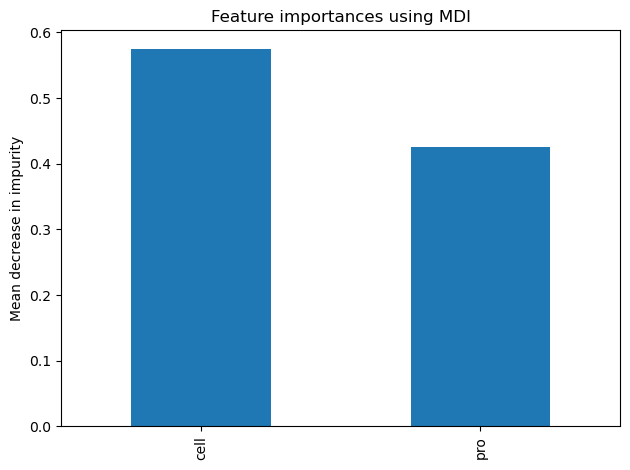

[[ 0.6932523   0.30674767]
 [ 0.4877532   0.5122468 ]
 [ 0.8775268   0.1224732 ]
 [ 0.7073946   0.29260537]
 [ 0.1926353   0.8073647 ]
 [ 0.7073946   0.29260537]
 [ 0.62723696  0.37276304]
 [-0.07349086  1.0734909 ]]
[False  True False False  True False False  True]


<Figure size 40000x12000 with 0 Axes>

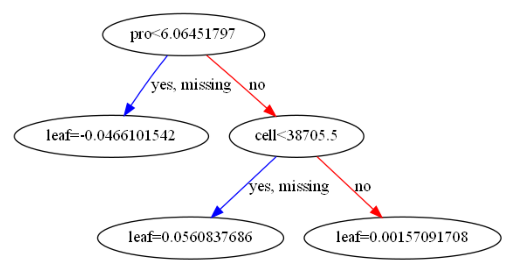

--------------------------------------------------------------------------------------------------


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import tree
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
import re
import random
from tensorflow.keras.utils import to_categorical
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
import xgboost as xgb
from xgboost import plot_tree
from xgboost import XGBClassifier
from xgboost import *
from dtreeviz import model

name="Cell pro 3-out.txt"
W_tree=3
class_names=["healing","non-healing"]

Treatment=pd.read_csv("../AD report/Cell Pro 3 train.csv")
Treatment_test=pd.read_csv("../AD report/Cell Pro 3 test.csv")

X_train=Treatment.iloc[:,1:]
y_train=Treatment.iloc[:,0]

X_test=Treatment_test.iloc[:,1:]
y_test=Treatment_test.iloc[:,0]

clf=XGBClassifier(tree_method="exact",
                  subsample ="0.5",
                  objective="reg:pseudohubererror"
                  
                  
    )




clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_pred = (y_pred > 0.5) 

print(classification_report(y_test,y_pred,output_dict=False,target_names=class_names))


accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", (accuracy*100),"%")

names=clf.get_booster().feature_names

importances = clf.feature_importances_
forest_importances = pd.Series(importances, index=names)

fig, ax = plt.subplots()
forest_importances.plot.bar( ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()
plt.show()



f = open(name, "w")
var=clf.get_booster().get_dump()
for line in var:
    f.write(f"{line}\n")
f.close()

print(clf.predict_proba(X_test))
print(y_pred)


plt.figure(figsize=(400, 120))
plot_tree(clf, num_trees=W_tree)
plt.show()








print("--------------------------------------------------------------------------------------------------")

target = 'key'



#Which_data=df_y_test
Which_data=y_train

from supertree import SuperTree
st = SuperTree(
    clf, 
    X_train, 
    Which_data, 
    names, 
    class_names
)
# Visualize the tree
st.show_tree(which_tree=W_tree)